In [1]:
from pathlib import Path
import shutil

In [2]:
source_dir = Path("../ESC-50-master/audio")
target_dir = Path("../data/raw")

target_dir.mkdir(parents=True, exist_ok=True)

print("Source:", source_dir.resolve())
print("Target:", target_dir.resolve())

Source: E:\Audio-Environmental-Classification\ESC-50-master\audio
Target: E:\Audio-Environmental-Classification\data\raw


In [3]:
from datasets import load_dataset

dataset = load_dataset(
    "renumics/esc50",
    split="train"
)

print(dataset)

e:\Audio-Environmental-Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset({
    features: ['src_file', 'fold', 'label', 'esc10', 'take', 'audio'],
    num_rows: 2000
})


In [4]:
selected_classes = [
    "dog",
    "cat",
    "rain",
    "clapping",
    "footsteps",
    "car_horn",
    "siren",
    "thunderstorm",
    "keyboard_typing",
    "church_bells"
]

label_names = dataset.features["label"].names

selected_ids = [
    label_names.index(class_name)
    for class_name in selected_classes
]

print("Selected classes:")
for class_name, class_id in zip(selected_classes, selected_ids):
    print(class_id, class_name)

Selected classes:
0 dog
5 cat
10 rain
22 clapping
25 footsteps
43 car_horn
42 siren
19 thunderstorm
32 keyboard_typing
46 church_bells


In [5]:
selected_indices = [
    i for i, label_id in enumerate(dataset["label"])
    if label_id in selected_ids
]

small_dataset = dataset.select(selected_indices)

print("Selected recordings:", len(small_dataset))

Selected recordings: 400


In [6]:
small_dataset = small_dataset.shuffle(seed=42)

small_dataset = small_dataset.select(
    range(min(250, len(small_dataset)))
)

print("Final recordings:", len(small_dataset))

Final recordings: 250


In [7]:
src_files = small_dataset["src_file"]

copied = 0
missing = 0

for filename in src_files:
    source_file = source_dir / filename
    target_file = target_dir / filename

    if source_file.exists():
        shutil.copy2(source_file, target_file)
        copied += 1
    else:
        print("Missing:", filename)
        missing += 1

print("Copied files:", copied)
print("Missing files:", missing)

Copied files: 250
Missing files: 0


In [8]:
wav_files = list(target_dir.glob("*.wav"))

print("WAV files in data/raw:", len(wav_files))

WAV files in data/raw: 250


In [9]:
import soundfile as sf

audio_path = target_dir / src_files[0]

audio_array, sample_rate = sf.read(audio_path)

print("File:", audio_path.name)
print("Sampling rate:", sample_rate)
print("Number of samples:", len(audio_array))
print("Duration:", len(audio_array) / sample_rate, "seconds")

File: 4-189838-A-22.wav
Sampling rate: 44100
Number of samples: 220500
Duration: 5.0 seconds


In [10]:
label_id = small_dataset["label"][0]
label = label_names[label_id]

print("File:", src_files[0])
print("Label ID:", label_id)
print("Label:", label)

File: 4-189838-A-22.wav
Label ID: 22
Label: clapping


In [11]:
from IPython.display import Audio, display

display(
    Audio(
        audio_array,
        rate=sample_rate
    )
)

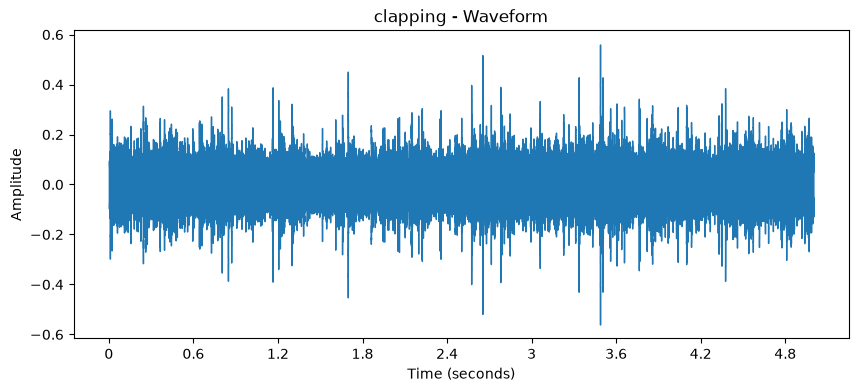

In [12]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10, 4))

librosa.display.waveshow(
    audio_array,
    sr=sample_rate
)

plt.title(f"{label} - Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()